# IPL Data Analysis

This project analyzes IPL match data using Pandas and NumPy.

## 1. Import Libraries

In [3]:
## 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [4]:
## 2. Load Dataset

df = pd.read_csv("C:/Users/gaikw/Downloads/archive (1)/IPL_Matches_Data_2008_2026.csv")

## 3. Understand Dataset

In [5]:
## 3. Understand Dataset

df.head()
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_name       1243 non-null   str    
 1   season           1243 non-null   str    
 2   match_number     1169 non-null   float64
 3   date             1243 non-null   str    
 4   city             1243 non-null   str    
 5   venue            1243 non-null   str    
 6   team1            1243 non-null   str    
 7   team2            1243 non-null   str    
 8   toss_winner      1243 non-null   str    
 9   toss_decision    1243 non-null   str    
 10  team1_runs       1243 non-null   int64  
 11  team1_wickets    1243 non-null   int64  
 12  team2_runs       1243 non-null   int64  
 13  team2_wickets    1243 non-null   int64  
 14  winner           1218 non-null   str    
 15  result_type      1243 non-null   str    
 16  win_by_runs      1243 non-null   int64  
 17  win_by_wickets   1243 non

## 4. Data Cleaning


### 4.1 Missing Values

First, I checked the missing values in the dataset.

The `winner` column has 25 missing values. After checking the `result_type`, I found that:

- 16 matches were tied
- 9 matches had no result

So, I will keep these missing values as they are because there is no single winner for these matches. team name.

In [6]:
df[df["winner"].isnull()]["result_type"].value_counts()

result_type
tie          16
no result     9
Name: count, dtype: int64

### 4.2 Match Number

The `match_number` column has some missing values.

I checked the seasons where the match number is missing to understand the data before making any changes.

In [7]:
df[df["match_number"].isnull()]["season"].value_counts()

season
2009/10    4
2011       4
2012       4
2013       4
2014       4
2015       4
2016       4
2017       4
2018       4
2019       4
2020/21    4
2021       4
2022       4
2023       4
2024       4
2025       4
2026       4
2007/08    3
2009       3
Name: count, dtype: int64

### 4.3 Missing Player of Match

The `player_of_match` column has 9 missing values.

I checked these rows and found that all 9 matches had no result.

Since there was no result, there was no Player of the Match. So I will keep these values as they are.

In [40]:
df[df["match_number"].isnull()][["season", "date", "team1", "team2", "result_type"]].head(10)

,season,date,team1,team2,result_type
55,2007/08,30-05-2008,Delhi Daredevils,Rajasthan Royals,complete
56,2007/08,31-05-2008,Chennai Super Kings,Kings XI Punjab,complete
57,2007/08,01-06-2008,Chennai Super Kings,Rajasthan Royals,complete
112,2009,22-05-2009,Delhi Daredevils,Deccan Chargers,complete
113,2009,23-05-2009,Royal Challengers Bangalore,Chennai Super Kings,complete
114,2009,24-05-2009,Royal Challengers Bangalore,Deccan Chargers,complete
171,2009/10,21-04-2010,Royal Challengers Bangalore,Mumbai Indians,complete
172,2009/10,22-04-2010,Chennai Super Kings,Deccan Chargers,complete
173,2009/10,24-04-2010,Royal Challengers Bangalore,Deccan Chargers,complete
174,2009/10,25-04-2010,Chennai Super Kings,Mumbai Indians,complete


In [41]:
df[df["player_of_match"].isnull()][
    ["season", "date", "team1", "team2", "winner", "result_type"]
]

,season,date,team1,team2,winner,result_type
241,2011,21-05-2011,Delhi Daredevils,Pune Warriors,NaN,no result
485,2015,29-04-2015,Royal Challengers Bangalore,Rajasthan Royals,NaN,no result
511,2015,17-05-2015,Royal Challengers Bangalore,Delhi Daredevils,NaN,no result
744,2019,30-04-2019,Royal Challengers Bangalore,Rajasthan Royals,NaN,no result
994,2023,03-05-2023,Lucknow Super Giants,Chennai Super Kings,NaN,no result
1138,2025,26-04-2025,Punjab Kings,Kolkata Knight Riders,NaN,no result
1149,2025,05-05-2025,Delhi Capitals,Sunrisers Hyderabad,NaN,no result
1152,2025,08-05-2025,Punjab Kings,Delhi Capitals,NaN,no result
1180,2026,06-04-2026,Kolkata Knight Riders,Punjab Kings,NaN,no result


### 4.4 Duplicate Rows

I also checked for duplicate rows in the dataset.

There are no duplicate rows, so no duplicate data needs to be removed.

In [43]:
df.duplicated().sum()

np.int64(0)

### 4.5 Date Conversion

The `date` column is currently stored as text.

I will convert it to datetime format so that I can work with dates easily later.

In [44]:
df["date"] = pd.to_datetime(df["date"])

C:\Users\gaikw\AppData\Local\Temp\ipykernel_10896\3228555721.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


In [45]:
df["date"].dtype

dtype('<M8[us]')

In [46]:
df["date"].head()

0   2008-04-18
1   2008-04-19
2   2008-04-19
3   2008-04-20
4   2008-04-20
Name: date, dtype: datetime64[us]

In [47]:
df["season"].value_counts().sort_index()

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
2026       74
Name: count, dtype: int64

### 4.6 Season Format

I checked the season values in the dataset.

Some seasons are written using two years, while others use a single year. I will keep the original season values as they are.

In [48]:
df["team1"].unique()

<StringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',       'Kolkata Knight Riders',
              'Mumbai Indians',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [49]:
df["team2"].unique()

<StringArray>
[      'Kolkata Knight Riders',         'Chennai Super Kings',
            'Rajasthan Royals',             'Deccan Chargers',
 'Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
              'Gujarat Titans',        'Lucknow Super Giants',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

### 4.7 Team Names

I checked the team names in both `team1` and `team2`.

Some teams have different names in different seasons. I will keep the original names as they are because they are part of the original dataset.

In [50]:
df[["team1_runs", "team2_runs"]].describe()

,team1_runs,team2_runs
count,1243.000000,1243.000000
mean,165.851167,157.349155
std,35.490847,34.613073
min,2.000000,0.000000
25%,144.000000,138.000000
50%,165.000000,160.000000
75%,189.000000,179.000000
max,287.000000,265.000000


### 4.8 Checking Run Values

I checked the basic statistics of `team1_runs` and `team2_runs`.

Both columns have values for all 1243 matches. The values also look reasonable, so I will keep them as they are.

In [51]:
df["result_type"].value_counts()

result_type
complete     1218
tie            16
no result       9
Name: count, dtype: int64

### 4.9 Result Type

I checked the different result types in the dataset.

There are three types of results:

- Complete
- Tie
- No result

All 1243 matches are covered by these three result types.

## 5. Exploratory Data Analysis

In this section, I will explore the dataset and look for some useful patterns.



In [54]:
df["season"].value_counts().sort_index()

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
2026       74
Name: count, dtype: int64

### 5.1 Matches Played in Each Season

I checked how many matches were played in each season.

Now I will visualize the number of matches played in each season.

In [1]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp314-cp314-win_amd64.whl.metadata (131 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl (240 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.66.0-cp314-cp314-win_amd64.whl (2.5 MB)
Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl (72 kB)
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------------------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


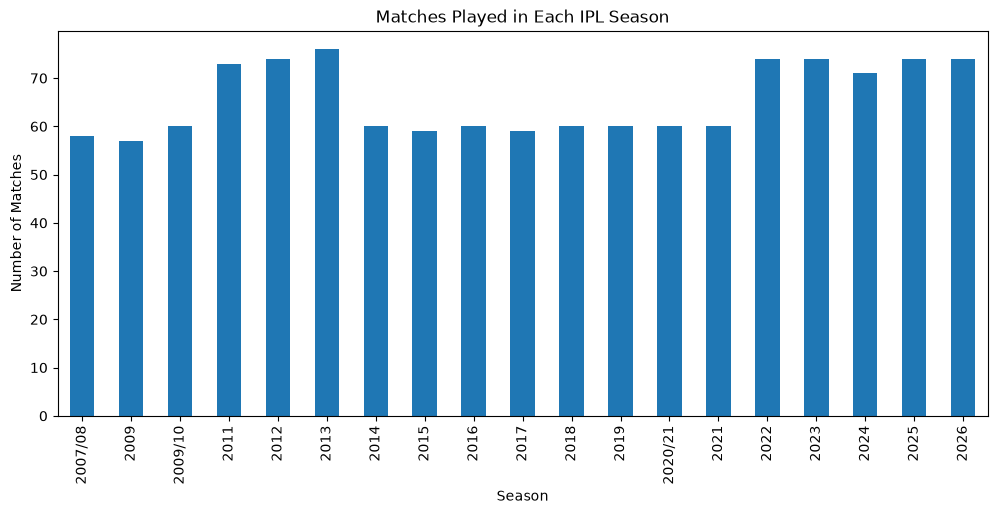

In [9]:
season_matches = df["season"].value_counts().sort_index()

season_matches.plot(
    kind="bar",
    figsize=(12, 5),
    title="Matches Played in Each IPL Season",
    xlabel="Season",
    ylabel="Number of Matches"
)

plt.show()

### Observation

The number of matches varies across IPL seasons.

Most seasons have around 60 matches, while some seasons have more matches.
The highest number of matches in this dataset is 76 in the 2013 season.

In [10]:
team_matches = pd.concat([df["team1"], df["team2"]]).value_counts()

team_matches

Mumbai Indians                 291
Kolkata Knight Riders          278
Chennai Super Kings            266
Rajasthan Royals               251
Royal Challengers Bangalore    240
Sunrisers Hyderabad            211
Kings XI Punjab                190
Delhi Daredevils               161
Delhi Capitals                 120
Punjab Kings                    88
Gujarat Titans                  77
Deccan Chargers                 75
Lucknow Super Giants            72
Pune Warriors                   46
Royal Challengers Bengaluru     46
Gujarat Lions                   30
Rising Pune Supergiant          16
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

### 5.2 Matches Played by Each Team

I combined the `team1` and `team2` columns to count how many matches each team played in the dataset.

Some teams appear with different names because team names changed across seasons.

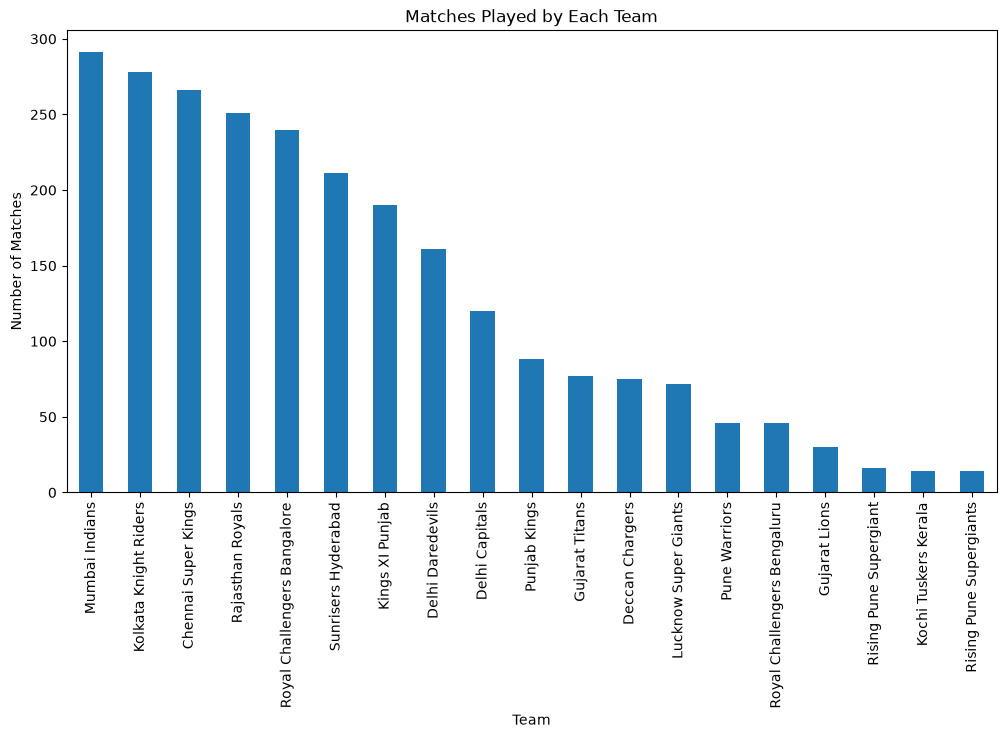

In [11]:
team_matches.plot(
    kind="bar",
    figsize=(12, 6),
    title="Matches Played by Each Team",
    xlabel="Team",
    ylabel="Number of Matches"
)

plt.xticks(rotation=90)
plt.show()

### Observation

The number of matches played is different for each team.

The counts are based on the team names as they appear in the dataset, so teams with different names across seasons are counted separately.

In [12]:
team_wins = df["winner"].value_counts()

team_wins

winner
Mumbai Indians                 155
Chennai Super Kings            148
Kolkata Knight Riders          140
Rajasthan Royals               123
Royal Challengers Bangalore    114
Sunrisers Hyderabad            102
Kings XI Punjab                 85
Delhi Daredevils                67
Delhi Capitals                  58
Gujarat Titans                  47
Punjab Kings                    41
Lucknow Super Giants            34
Deccan Chargers                 29
Royal Challengers Bengaluru     29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

### 5.3 Matches Won by Each Team

I counted the number of matches won by each team using the `winner` column.

Matches with no winner, such as ties and no-result matches, are not included in this count.

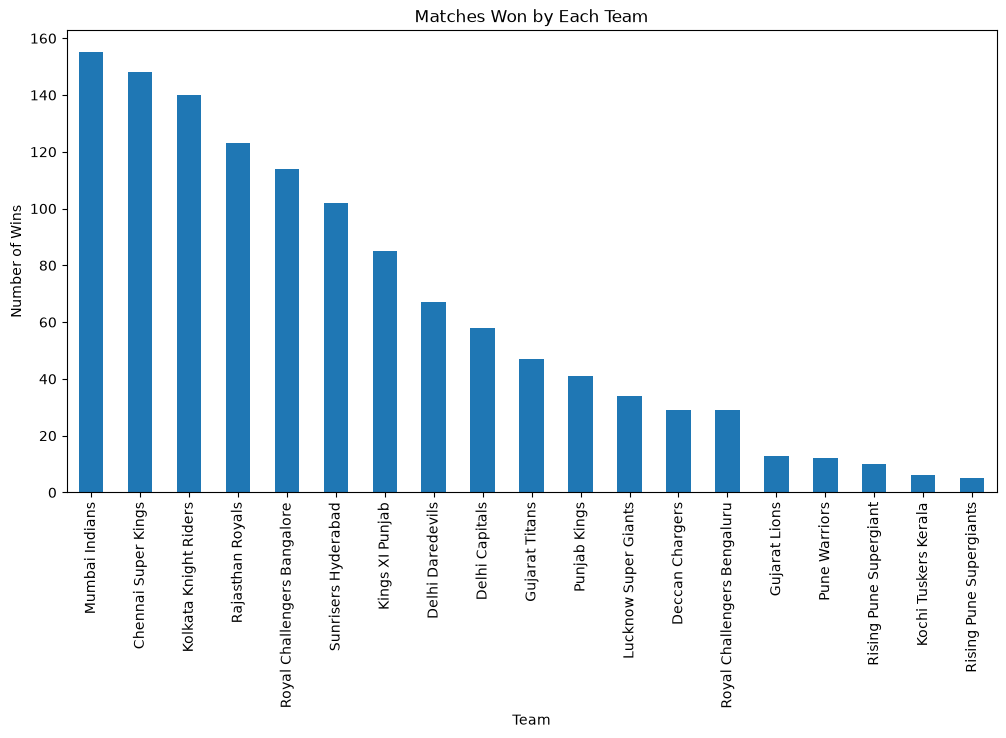

In [13]:
team_wins.plot(
    kind="bar",
    figsize=(12, 6),
    title="Matches Won by Each Team",
    xlabel="Team",
    ylabel="Number of Wins"
)

plt.xticks(rotation=90)
plt.show()

### Observation

The number of wins is different for each team.

The `winner` column does not include matches with no winner, such as ties and no-result matches.

### 5.4 Toss Decision

I checked what teams chose after winning the toss.

There are two choices in the dataset:

- Field
- Bat

Fielding was chosen more often than batting.

In [ ]:
df["toss_decision"].value_counts()

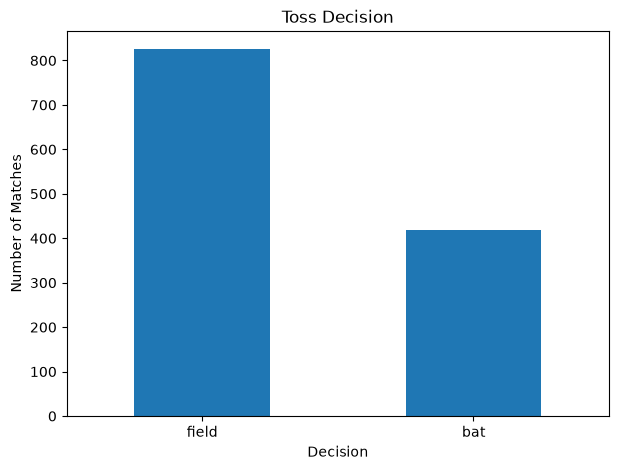

In [15]:
toss_decision = df["toss_decision"].value_counts()

toss_decision.plot(
    kind="bar",
    figsize=(7, 5),
    title="Toss Decision",
    xlabel="Decision",
    ylabel="Number of Matches"
)

plt.xticks(rotation=0)
plt.show()

### Observation

Fielding was chosen more often after winning the toss than batting.

In [16]:
toss_and_match_winner = df[df["toss_winner"] == df["winner"]]

len(toss_and_match_winner)

628

In [17]:
toss_win_rate = (628 / df["winner"].notna().sum()) * 100

toss_win_rate

np.float64(51.55993431855501)

### Observation

Among the matches that had a winner, the team that won the toss also won the match in about 51.56% of the matches.

In [18]:
toss_match_result = pd.Series({
    "Toss Winner Won": 628,
    "Toss Winner Lost": 1218 - 628
})

toss_match_result

Toss Winner Won     628
Toss Winner Lost    590
dtype: int64

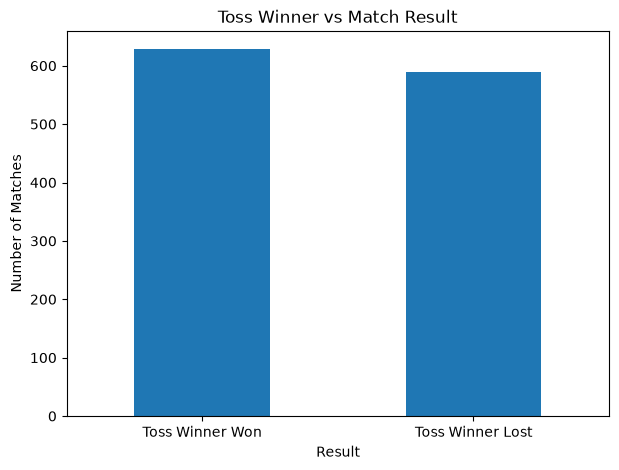

In [19]:
toss_match_result.plot(
    kind="bar",
    figsize=(7, 5),
    title="Toss Winner vs Match Result",
    xlabel="Result",
    ylabel="Number of Matches"
)

plt.xticks(rotation=0)
plt.show()

### Observation

Among the matches that had a winner, the toss winner won 628 matches and lost 590 matches.

The toss winner won the match in about 51.56% of these matches.

In [20]:
player_awards = df["player_of_match"].value_counts()

player_awards.head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
V Kohli           22
RG Sharma         21
MS Dhoni          18
DA Warner         18
SP Narine         18
RA Jadeja         17
KL Rahul          17
SR Watson         16
Name: count, dtype: int64

### 5.5 Player of the Match Awards

I counted how many times each player received the Player of the Match award.

The table below shows the top 10 players based on the number of awards in this dataset.

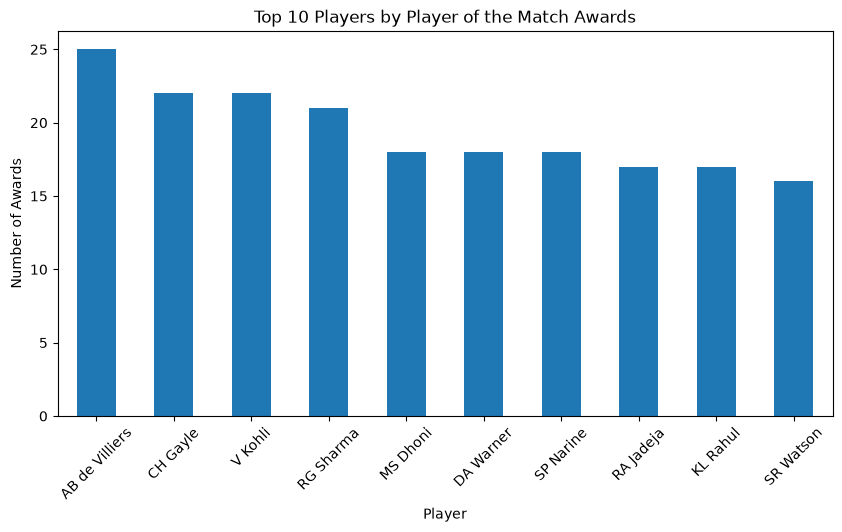

In [21]:
top_players = player_awards.head(10)

top_players.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Players by Player of the Match Awards",
    xlabel="Player",
    ylabel="Number of Awards"
)

plt.xticks(rotation=45)
plt.show()

### Observation

The chart shows the top 10 players based on the number of Player of the Match awards in the dataset.

AB de Villiers has 25 awards, followed by CH Gayle and V Kohli with 22 awards each.

In [22]:
venue_matches = df["venue"].value_counts()

venue_matches.head(10)

venue
Eden Gardens                                 77
Wankhede Stadium                             73
M Chinnaswamy Stadium                        65
Feroz Shah Kotla                             60
Wankhede Stadium, Mumbai                     59
Rajiv Gandhi International Stadium, Uppal    49
MA Chidambaram Stadium, Chepauk              48
Sawai Mansingh Stadium                       47
Dubai International Cricket Stadium          46
MA Chidambaram Stadium, Chepauk, Chennai     41
Name: count, dtype: int64

### 5.6 Matches Played at Each Venue

I counted the number of matches played at each venue.

Some venues appear with slightly different names in the dataset, so I have kept the original venue names.

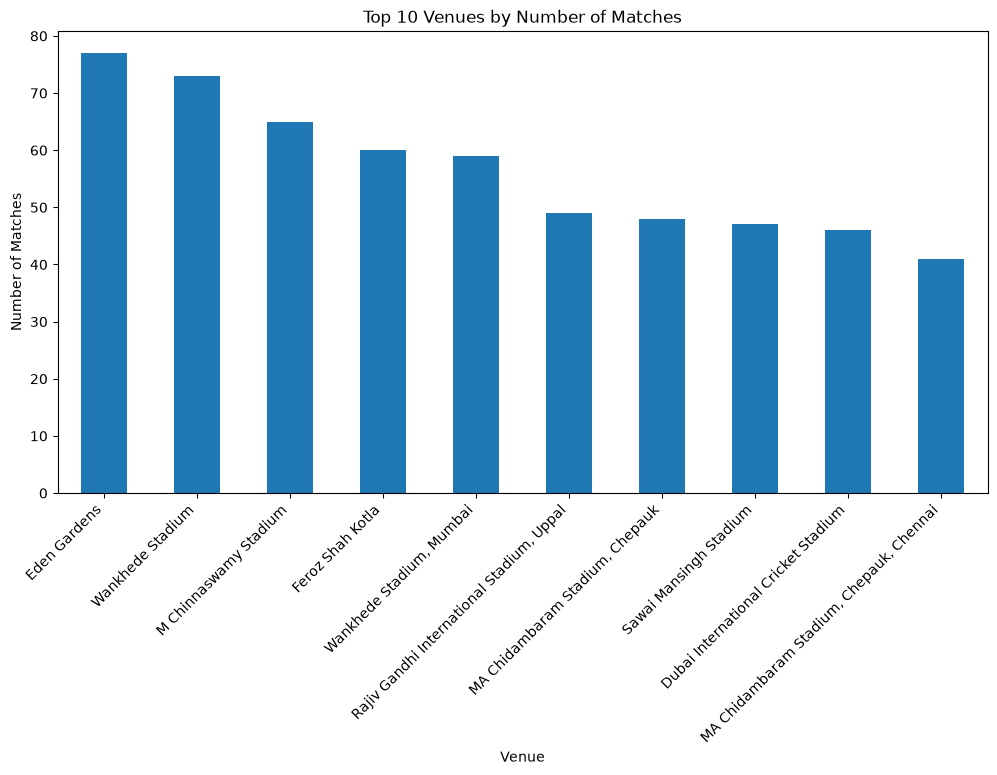

In [23]:
top_venues = venue_matches.head(10)

top_venues.plot(
    kind="bar",
    figsize=(12, 6),
    title="Top 10 Venues by Number of Matches",
    xlabel="Venue",
    ylabel="Number of Matches"
)

plt.xticks(rotation=45, ha="right")
plt.show()

### Observation

The chart shows the top 10 venues based on the number of matches in the dataset.

Some venues appear with slightly different names, so the counts are based on the original venue names.

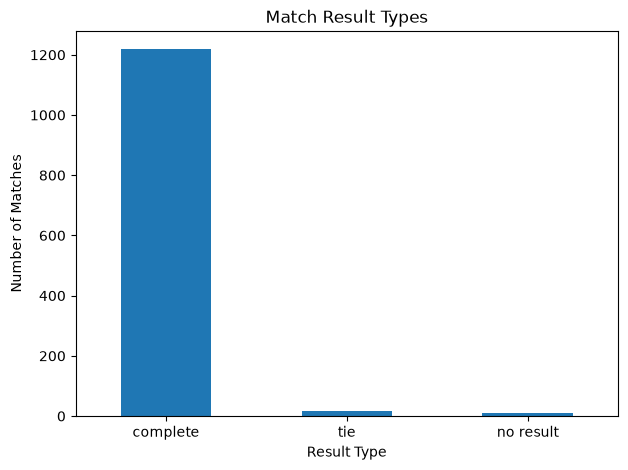

In [24]:
result_counts = df["result_type"].value_counts()

result_counts.plot(
    kind="bar",
    figsize=(7, 5),
    title="Match Result Types",
    xlabel="Result Type",
    ylabel="Number of Matches"
)

plt.xticks(rotation=0)
plt.show()

### Observation

Most matches in the dataset have a complete result.

There are also a small number of tied and no-result matches.

## 6. NumPy Analysis

### 6.1 Average Runs

I will use NumPy to calculate the average runs scored by both teams.

In [25]:
team1_avg = np.mean(df["team1_runs"])
team2_avg = np.mean(df["team2_runs"])

print("Average runs by Team 1:", team1_avg)
print("Average runs by Team 2:", team2_avg)

Average runs by Team 1: 165.85116653258245
Average runs by Team 2: 157.34915526950925


### Observation

Using NumPy, I calculated the average runs scored by both teams.

Team 1 has an average of about 165.85 runs, while Team 2 has an average of about 157.35 runs.

6.2 Highest & Lowest Runs

In [26]:
team1_max = np.max(df["team1_runs"])
team1_min = np.min(df["team1_runs"])

team2_max = np.max(df["team2_runs"])
team2_min = np.min(df["team2_runs"])

print("Team 1 - Highest:", team1_max)
print("Team 1 - Lowest:", team1_min)
print("Team 2 - Highest:", team2_max)
print("Team 2 - Lowest:", team2_min)

Team 1 - Highest: 287
Team 1 - Lowest: 2
Team 2 - Highest: 265
Team 2 - Lowest: 0


### Observation

Using NumPy, I found the highest and lowest scores for both teams.

Team 1 has a highest score of 287 and a lowest score of 2.
Team 2 has a highest score of 265 and a lowest score of 0.

6.3 Total Runs

In [27]:
total_runs = df["team1_runs"].to_numpy() + df["team2_runs"].to_numpy()

print("Total runs in all matches:", np.sum(total_runs))
print("Average total runs per match:", np.mean(total_runs))

Total runs in all matches: 401738
Average total runs per match: 323.2003218020917


### Observation

Using NumPy, I calculated the total runs across both teams for each match.

The dataset contains 401,738 total runs, with an average of about 323.20 runs per match.

6.4 Standard Deviation

In [29]:
total_runs_std = np.std(total_runs)

print("Standard deviation of total runs:", total_runs_std)

Standard deviation of total runs: 63.475786553433544


### Observation

Using NumPy, I calculated the standard deviation of total runs.

The standard deviation is about 63.48 runs, which shows the spread of total runs around the average.

6.5 Median

In [30]:
total_runs_median = np.median(total_runs)

print("Median total runs:", total_runs_median)

Median total runs: 323.0


### Observation

Using NumPy, I calculated the median of total runs.

The median total runs is 323, which is very close to the average total runs of about 323.20.

6.6 Percentile & IQR

In [31]:
q1 = np.percentile(total_runs, 25)
q3 = np.percentile(total_runs, 75)

print("25th Percentile:", q1)
print("75th Percentile:", q3)

25th Percentile: 287.0
75th Percentile: 362.0


### Observation

Using NumPy, I calculated the 25th and 75th percentiles of total runs.

The 25th percentile is 287 runs and the 75th percentile is 362 runs.

This means the middle 50% of matches have total runs between 287 and 362.

In [32]:
iqr = q3 - q1

print("Interquartile Range:", iqr)

Interquartile Range: 75.0


### Observation

The Interquartile Range (IQR) of total runs is 75.

It represents the spread of the middle 50% of matches, from 287 to 362 total runs.h

6.7 Run Difference Between Teams

In [33]:
run_difference = np.abs(
    df["team1_runs"].to_numpy() - df["team2_runs"].to_numpy()
)

print("Average run difference:", np.mean(run_difference))
print("Maximum run difference:", np.max(run_difference))

Average run difference: 16.86082059533387
Maximum run difference: 200


### Observation

Using NumPy, I calculated the difference between the runs scored by both teams.

The average run difference is about 16.86 runs.
The maximum run difference is 200 runs.

6.8 NumPy — Winning Margin Analysis

In [34]:
run_margin = df["win_by_runs"].dropna().to_numpy()

print("Average winning margin by runs:", np.mean(run_margin))
print("Maximum winning margin by runs:", np.max(run_margin))

Average winning margin by runs: 13.932421560740146
Maximum winning margin by runs: 146


### Observation

Using NumPy, I calculated the winning margin for matches won by runs.

The average winning margin is about 13.93 runs.
The maximum winning margin is 146 runs.

6.9 Observation

In [35]:
wicket_margin = df["win_by_wickets"].dropna().to_numpy()

print("Average winning margin by wickets:", np.mean(wicket_margin))
print("Maximum winning margin by wickets:", np.max(wicket_margin))

Average winning margin by wickets: 3.2767497988736927
Maximum winning margin by wickets: 10


### Observation

Using NumPy, I calculated the winning margin for matches won by wickets.

The average winning margin is about 3.28 wickets.
The maximum winning margin is 10 wickets.

6.10 Team 1 vs Team 2 — Average Runs

In [36]:
average_scores = np.array([team1_avg, team2_avg])

print("Average score of Team 1:", average_scores[0])
print("Average score of Team 2:", average_scores[1])
print("Difference:", np.abs(average_scores[0] - average_scores[1]))

Average score of Team 1: 165.85116653258245
Average score of Team 2: 157.34915526950925
Difference: 8.5020112630732


### Observation

Using NumPy, I compared the average runs of Team 1 and Team 2.

Team 1 has an average score of about 165.85 runs.
Team 2 has an average score of about 157.35 runs.

The difference between the two averages is about 8.50 runs.

## 7. Key Insights

- The dataset contains 1,243 IPL matches from different seasons.
- Most matches in the dataset have a complete result, while some matches ended in a tie or no result.
- Fielding was chosen more often than batting after winning the toss.
- The toss winner won 628 out of 1,218 matches that had a winner.
- Mumbai Indians has the highest number of wins among the team names in this dataset.
- AB de Villiers has the highest number of Player of the Match awards in the dataset, with 25 awards.
- The average total runs per match is about 323.20.
- The median total runs per match is 323.
- The middle 50% of matches have total runs between 287 and 362.
- The average difference between the two teams' scores is about 16.86 runs.

## 8. Conclusion

This project helped me practice Python, Pandas, NumPy and data visualization using an IPL matches dataset.

I explored match results, team performance, toss decisions, Player of the Match awards, venues and scoring patterns.

I also used NumPy to calculate statistical measures such as mean, median, standard deviation, percentiles and IQR.

This project helped me understand how Python libraries can be used to explore and analyze a real-world dataset.